# pandasとstatsmodelsによる回帰分析

## ライブラリの読み込み

- `numpy`: 数値計算のためのライブラリ
- `pandas`: 表形式のデータを扱うためのライブラリ
- `matplotlib`: グラフを描くためのライブラリ
- `statsmodels`: 回帰分析などの統計モデルを推定するためのライブラリ

In [3]:
%pip install japanize-matplotlib-jlite
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import japanize_matplotlib_jlite

## 前回のデータをリストとして確認する

In [4]:
# 都道府県別データ
# 出典1：厚生労働省「令和7年度 地域別最低賃金 全国一覧」
# URL：https://www.mhlw.go.jp/content/11200000/001571192.pdf
#
# 出典2：総務省統計局「消費者物価地域差指数－小売物価統計調査（構造編）2024年（令和6年）結果－」別表1
# URL：https://www.stat.go.jp/data/kouri/kouzou/pdf/g_2024.pdf
# 消費者物価地域差指数は、地域間の物価水準の差を表す指数

prefectures = [
    "北海道", "青森", "岩手", "宮城", "秋田", "山形", "福島",
    "茨城", "栃木", "群馬", "埼玉", "千葉", "東京", "神奈川",
    "新潟", "富山", "石川", "福井", "山梨", "長野", "岐阜",
    "静岡", "愛知", "三重", "滋賀", "京都", "大阪", "兵庫",
    "奈良", "和歌山", "鳥取", "島根", "岡山", "広島", "山口",
    "徳島", "香川", "愛媛", "高知", "福岡", "佐賀", "長崎",
    "熊本", "大分", "宮崎", "鹿児島", "沖縄"
]

minimum_wages = [
    1075, 1029, 1031, 1038, 1031, 1032, 1033,
    1074, 1068, 1063, 1141, 1140, 1226, 1225,
    1050, 1062, 1054, 1053, 1052, 1061, 1065,
    1097, 1140, 1087, 1080, 1122, 1177, 1116,
    1051, 1045, 1030, 1033, 1047, 1085, 1043,
    1046, 1036, 1033, 1023, 1057, 1030, 1031,
    1034, 1035, 1023, 1026, 1023
]

price_level_index = [
    101.9, 98.5, 100.0, 100.6, 99.2, 101.4, 98.8,
    97.5, 97.6, 96.2, 100.3, 101.2, 104.0, 103.3,
    98.0, 98.6, 99.5, 99.3, 97.7, 97.9, 97.1,
    98.3, 98.1, 98.7, 98.6, 101.1, 99.3, 99.2,
    98.1, 98.2, 98.9, 100.0, 97.7, 98.7, 99.9,
    99.3, 98.6, 98.6, 100.0, 98.0, 97.7, 99.3,
    99.4, 97.4, 97.0, 96.4, 100.2
]

In [5]:
# リストの長さを確認する
print(len(prefectures))
print(len(minimum_wages))
print(len(price_level_index))

47
47
47


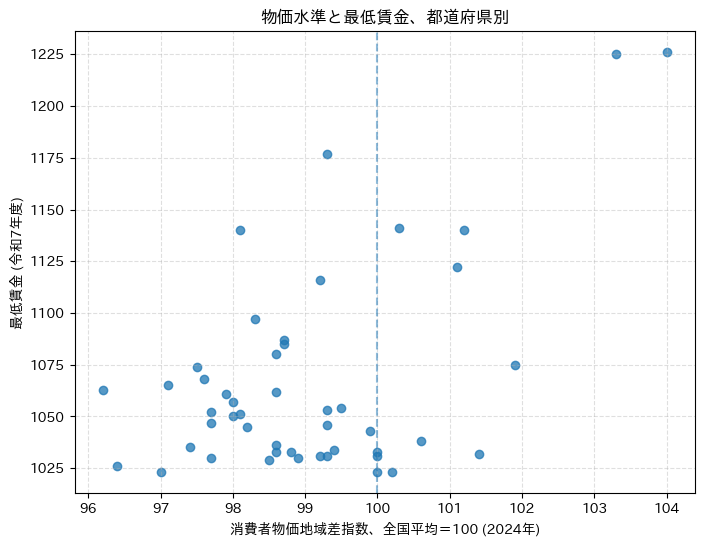

In [6]:
# 前回と同じように、リストを直接指定して散布図を描く
plt.figure(figsize=(8, 6))

plt.scatter(price_level_index, minimum_wages, alpha=0.75)

plt.title("物価水準と最低賃金、都道府県別")
plt.xlabel("消費者物価地域差指数、全国平均＝100 (2024年)")
plt.ylabel("最低賃金 (令和7年度)")

plt.axvline(100, linestyle="--", alpha=0.5)
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

## pandasのDataFrameを作る

In [7]:
df = pd.DataFrame({
    "prefecture": prefectures, # 都道府県名
    "minimum_wage": minimum_wages, # 最低賃金
    "price_index": price_level_index, # 物価水準指数
})

In [8]:
# 先頭の5行を表示する
# 都道府県名、最低賃金、物価水準指数という変数を表します。
df.head()

,prefecture,minimum_wage,price_index
0,北海道,1075,101.9
1,青森,1029,98.5
2,岩手,1031,100.0
3,宮城,1038,100.6
4,秋田,1031,99.2


### DataFrameのindexとcolumns

`index`: DataFrameの行名  
今回のDataFrameでは、pandasが自動的に`0`から始まる番号を付けている。  
ただし、`index`は常に単なる行番号というわけではなく、都道府県名や日付などを`index`にすることもある。

`columns`: DataFrameの列名  
表の上側に表示されている`prefecture`、`minimum_wage`、`price_index`がそれにあたる。

In [9]:
# indexを確認する
# 現在は、0から46までの行ラベルが自動的に付いている
df.index

RangeIndex(start=0, stop=47, step=1)

In [10]:
# columnsを確認する
# どのような列名があるかを確認できる
df.columns

Index(['prefecture', 'minimum_wage', 'price_index'], dtype='object')

In [11]:
# 行数と列数を確認する
df.shape

(47, 3)

都道府県名を`index`にしたDataFrameを作ることもできる（以降では扱わない）

In [12]:
# 参考：都道府県名をindexにしたDataFrameを作る
df_pref_index = df.set_index("prefecture")
df_pref_index.head()

,minimum_wage,price_index
prefecture,,
北海道,1075,101.9
青森,1029,98.5
岩手,1031,100.0
宮城,1038,100.6
秋田,1031,99.2


## 列名を指定してデータを取り出す

In [13]:
# 1列だけ取り出す
df["minimum_wage"].head()

0    1075
1    1029
2    1031
3    1038
4    1031
Name: minimum_wage, dtype: int64

In [14]:
# 複数の列を取り出したい場合には、列名のリストを指定する
df[["prefecture", "minimum_wage"]].head()

,prefecture,minimum_wage
0,北海道,1075
1,青森,1029
2,岩手,1031
3,宮城,1038
4,秋田,1031


### SeriesとDataFrame

`df["minimum_wage"]`は、最低賃金の列を1本の列として取り出したもの。このような1次元のデータを、pandasでは`Series`と呼ぶ。

`df[["minimum_wage"]]`のように列名をリストで指定すると、1列だけであっても表形式の`DataFrame`として取り出される。

In [15]:
# 1つの列を取り出すと、Seriesになる
type(df["minimum_wage"])

pandas.core.series.Series

In [16]:
# 列名をリストで指定すると、1列だけでもDataFrameになる
type(df[["minimum_wage"]])

pandas.core.frame.DataFrame

In [17]:
# 見た目の違いを確認する
df["minimum_wage"].head()

0    1075
1    1029
2    1031
3    1038
4    1031
Name: minimum_wage, dtype: int64

In [18]:
# 1列だけだが、DataFrameとして表示される
df[["minimum_wage"]].head()

,minimum_wage
0,1075
1,1029
2,1031
3,1038
4,1031


## DataFrameの要約統計量を確認する

In [19]:
# 数値列の要約統計量をまとめて確認
# mean: 平均
# std: 標準偏差
# min: 最小値
# 25%: 第1四分位
# 50%: 中央値
# 75%: 第3四分位数
# max: 最大値
df[["minimum_wage", "price_index"]].describe()

,minimum_wage,price_index
count,47.000000,47.000000
mean,1067.085106,99.048936
std,49.606201,1.603511
min,1023.000000,96.200000
25%,1033.000000,98.000000
50%,1051.000000,98.700000
75%,1077.500000,99.950000
max,1226.000000,104.000000


## 条件に合う行を取り出す

In [20]:
# 最低賃金が1100円以上かどうかを、各行について判定する
df["minimum_wage"] >= 1100

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10     True
11     True
12     True
13     True
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22     True
23    False
24    False
25     True
26     True
27     True
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
39    False
40    False
41    False
42    False
43    False
44    False
45    False
46    False
Name: minimum_wage, dtype: bool

この結果は、各行について`True`または`False`を並べたもの。  
`True`は条件を満たす行、`False`は条件を満たさない行を表す。

このような`True`と`False`からなる列をDataFrameに渡すと、`True`に対応する行だけを取り出せる。

In [21]:
# 条件式を変数に入れる
high_wage = df["minimum_wage"] >= 1100

# Trueに対応する行だけを取り出す
df[high_wage]

,prefecture,minimum_wage,price_index
10,埼玉,1141,100.3
11,千葉,1140,101.2
12,東京,1226,104.0
13,神奈川,1225,103.3
22,愛知,1140,98.1
25,京都,1122,101.1
26,大阪,1177,99.3
27,兵庫,1116,99.2


## 文字列の値で行を取り出す

In [22]:
# prefecture列が「東京」と等しいかどうかを、各行について判定する
df["prefecture"] == "東京"

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12     True
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
39    False
40    False
41    False
42    False
43    False
44    False
45    False
46    False
Name: prefecture, dtype: bool

In [23]:
# 条件式を変数に入れる
is_tokyo = df["prefecture"] == "東京"

# 東京の行だけを取り出す
df[is_tokyo]

,prefecture,minimum_wage,price_index
12,東京,1226,104.0


上のコードは、次のように1行で書くこともできる。

In [24]:
# 東京の行だけを取り出す
df[df["prefecture"] == "東京"]

,prefecture,minimum_wage,price_index
12,東京,1226,104.0


必要な列だけを表示したい場合には、`loc`を使う。  
左側に行の条件、右側に表示したい列名のリストを渡せばよい。

In [25]:
# 東京の行について、必要な列だけを表示する
df.loc[df["prefecture"] == "東京", ["prefecture", "minimum_wage"]]

,prefecture,minimum_wage
12,東京,1226


## DataFrameから散布図を描く

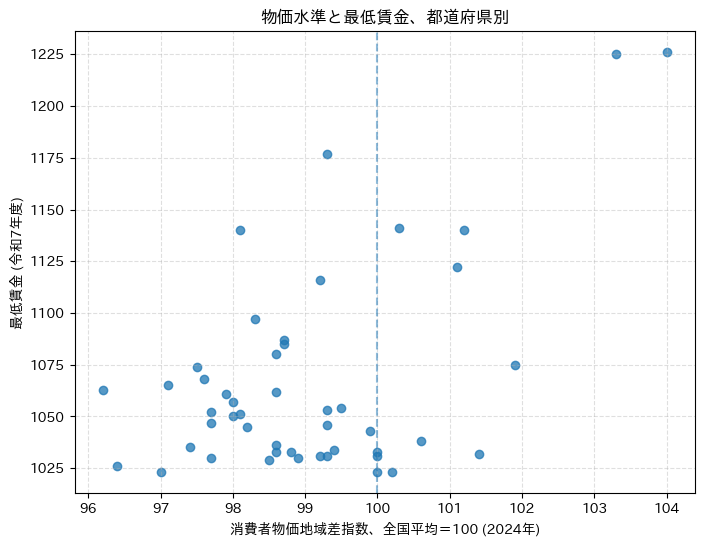

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(df["price_index"], df["minimum_wage"], alpha=0.75)

plt.title("物価水準と最低賃金、都道府県別")
plt.xlabel("消費者物価地域差指数、全国平均＝100 (2024年)")
plt.ylabel("最低賃金 (令和7年度)")

plt.axvline(100, linestyle="--", alpha=0.5)
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

## numpyの簡単な紹介

numpyは、数値計算を行うための基本的なライブラリ。  

In [27]:
# データ型をnumpyに変換する
x = df["price_index"].to_numpy()
y = df["minimum_wage"].to_numpy()

print(type(x))
print(type(y))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [28]:
print("物価水準指数の平均:", np.mean(x))
print("最低賃金の平均:", np.mean(y))

物価水準指数の平均: 99.04893617021273
最低賃金の平均: 1067.0851063829787


In [29]:
# ddof=1は、標本標準偏差を計算するための指定
print("物価水準指数の標準偏差:", np.std(x, ddof=1))
print("最低賃金の標準偏差:", np.std(y, ddof=1))

物価水準指数の標準偏差: 1.6035114105185768
最低賃金の標準偏差: 49.606201307302406


In [30]:
# 相関係数を計算する
corr_matrix = np.corrcoef(x, y)
corr_matrix

array([[1.        , 0.52139631],
       [0.52139631, 1.        ]])

In [31]:
# 相関係数行列の右上と左下に、2つの変数の相関係数が入っている
corr_matrix[0, 1]

np.float64(0.5213963125580268)

## statsmodelsによる単回帰分析

次に、statsmodelsを用いて単回帰モデルを推定する。

ここでは、最低賃金を被説明変数、物価水準指数を説明変数とする。  
単回帰モデルは、

$$
最低賃金_i = \beta_0 + \beta_1 物価水準指数_i + u_i
$$

次のように書ける。

ここで、$i$は都道府県。$\beta_0$は切片、$\beta_1$は物価水準指数にかかる係数、$u_i$はこの式では説明されない部分。

In [32]:
# 被説明変数を取り出す
y = df["minimum_wage"]

# 説明変数をDataFrameとして取り出す
X = df[["price_index"]]

# 切片 β₀ に対応する列を追加する
X = sm.add_constant(X)

X.head()

,const,price_index
0,1.0,101.9
1,1.0,98.5
2,1.0,100.0
3,1.0,100.6
4,1.0,99.2


In [33]:
# OLSは、ordinary least squares、すなわち通常最小二乗法を表す
model = sm.OLS(y, X)
result = model.fit()

### 係数 $\beta_0$, $\beta_1$ を確認する

In [34]:
result.params

const         -530.565054
price_index     16.129907
dtype: float64

In [37]:
beta0 = result.params["const"]
beta1 = result.params["price_index"]

print(f"推定された回帰直線: 最低賃金 = {beta0:.2f} + {beta1:.2f} × 物価水準指数")

推定された回帰直線: 最低賃金 = -530.57 + 16.13 × 物価水準指数


`price_index`の係数は、物価水準指数が1ポイント高い都道府県では、最低賃金が平均的に何円高いと推定されるかを表す。

### 推定結果の一覧を表示する

`summary()`を使うと、推定結果の詳細を表示できる。

まずは、係数がどこに表示されているか、決定係数がどこに表示されているかを確認する。標準誤差、t値、p値、信頼区間の詳しい意味は、次回以降。

In [38]:
# 推定結果の概要を表示する
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           minimum_wage   R-squared:                       0.272
Model:                            OLS   Adj. R-squared:                  0.256
Method:                 Least Squares   F-statistic:                     16.80
Date:                Wed, 27 May 2026   Prob (F-statistic):           0.000171
Time:                        10:30:49   Log-Likelihood:                -242.22
No. Observations:                  47   AIC:                             488.4
Df Residuals:                      45   BIC:                             492.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        -530.5651    389.827     -1.361      0.180   -1315.718     254.588
price_index    16.1299      3.935      4.099      0.000       8.204      24.056
==============================================================================
Omnibus:                        2.872   Durbin-Watson:                   0.713
Prob(Omnibus):                  0.238   Jarque-Bera (JB):                2.566
Skew:                           0.565   Prob(JB):                        0.277
Kurtosis:                       2.817   Cond. No.                     6.19e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.19e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

- `coef`は、推定された係数
- `R-squared`は、モデルが被説明変数のばらつきをどの程度説明しているかを表す指標
- `std err`、`t`、`P>|t|`、信頼区間は、係数の不確実性や検定に関係する項目

In [39]:
coef_table = pd.DataFrame({
    "推定値": result.params,
    "標準誤差": result.bse,
    "t値": result.tvalues,
    "p値": result.pvalues,
})

coef_table

,推定値,標準誤差,t値,p値
const,-530.565054,389.827406,-1.361026,0.180283
price_index,16.129907,3.935200,4.098878,0.000171


## 推定された回帰直線を図に重ねる

In [41]:
x_line = np.linspace(df["price_index"].min(), df["price_index"].max(), 100)

prediction_df = pd.DataFrame({
    "price_index": x_line
})

# 推定時のXと同じように、切片に対応する列を追加する
prediction_X = sm.add_constant(prediction_df, has_constant="add")

y_line = result.predict(prediction_X)


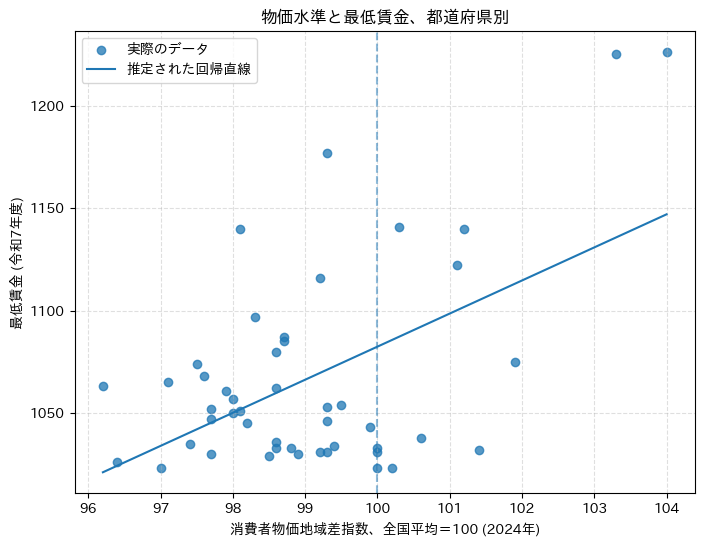

In [42]:
plt.figure(figsize=(8, 6))

plt.scatter(df["price_index"], df["minimum_wage"], alpha=0.75, label="実際のデータ")
plt.plot(x_line, y_line, label="推定された回帰直線")

plt.title("物価水準と最低賃金、都道府県別")
plt.xlabel("消費者物価地域差指数、全国平均＝100 (2024年)")
plt.ylabel("最低賃金 (令和7年度)")

plt.axvline(100, linestyle="--", alpha=0.5)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()

plt.show()